In [55]:
#1
#For a function like e^2ix , discretizing and encoding it into a quantum state already gives a superposition in the frequency domain. To extract the frequency index, we apply the Inverse QFT. In essence, function encoding puts us in the Fourier basis, so we reverse the process with IQFT:

Measurement counts: {'1110': 4786, '0010': 4814}


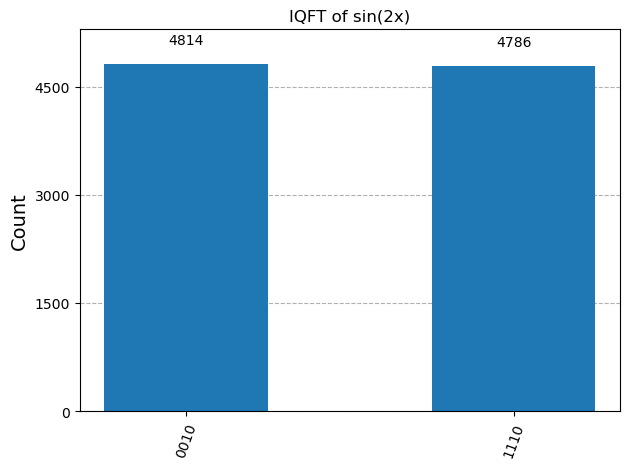

In [56]:
#2
%matplotlib inline
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import base64
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt


# Define parameters
num_qubits = 4
num_samples = 2**num_qubits
domain = np.linspace(0, 2 * np.pi, num_samples, endpoint=False)

# Function to encode
def signal(k):
    values = np.sin(k * domain)
    return values / np.linalg.norm(values)

# Build quantum circuit
circuit = QuantumCircuit(num_qubits)
iqft_gate = QFT(num_qubits, inverse=True)

circuit.initialize(signal(2), circuit.qubits)
circuit.append(iqft_gate, circuit.qubits)
circuit.measure_all()

# Run simulation
sim = AerSimulator()
compiled_circuit = transpile(circuit, sim)
job = sim.run(compiled_circuit, shots=9600)
results = job.result()
measurement_counts = results.get_counts()

# Display results
print("Measurement counts:", measurement_counts)
plot_histogram(measurement_counts, title="IQFT of sin(2x)")



In [57]:
#3
# sin(2x) has equal contributions from both e^2ix and e^-2ix. As we are working with 4 qubits, in a discrete fourier transform, frequencies are modulo 16 (2^4)
# The freq of 2 shows up normaly but the freq of -2 shows up as 16-2 which is 14


Measurement counts: {'0000': 203, '1000': 2912, '1011': 622, '1101': 873, '1100': 1254, '0011': 827, '0111': 358, '1001': 339, '0100': 1206, '0001': 41, '0010': 132, '0101': 618, '0110': 20, '1111': 37, '1110': 141, '1010': 17}


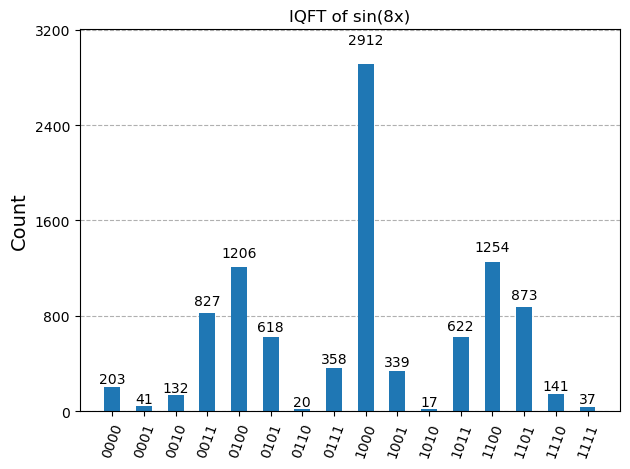

In [58]:

# Parameters
n_qubits = 4
n_points = 2**n_qubits
x_vals = np.linspace(0, 2 * np.pi, n_points, endpoint=False)

# Function definition
def generate_wave(freq):
    data = np.sin(freq * x_vals)
    return data / np.linalg.norm(data)

# Create circuit
qc = QuantumCircuit(n_qubits)
iqft = QFT(n_qubits, inverse=True)

qc.initialize(generate_wave(8), qc.qubits)
qc.append(iqft, qc.qubits)
qc.measure_all()

# Simulate
sim = AerSimulator()
compiled = transpile(qc, sim)
job = sim.run(compiled, shots=9600)
results = job.result()
freq_counts = results.get_counts()

# Output
print("Measurement counts:", freq_counts)
plot_histogram(freq_counts, title="IQFT of sin(8x)")

# 4
"""
A discrete Fourier transform of sin(8x) over a discrete basis shows a sharp peak at index 8 but also has smaller side peaks. 
This happens because the DFT computes inner products between the signal and each of the 16 orthonormal Fourier basis vectors. 
Ideally, only the basis vector at frequency 8 would yield a non-zero inner product, however, in the discrete case, the sampling is finite, and the sine function does not align perfectly with the DFT basis unless its frequency and phase match exactly. 
So even small mismatches result in non-zero inner products with nearby basis vectors. Since we’re not taking an infinite number of samples, these mismatches don’t average out to zero. 
This effect is known as spectral leakage.
"""

In [60]:
print(

'Amplitude encoding becomes impractical as dataset size increases. Preparing a generic quantum state with arbitrary amplitudes requires O(2^n) gates making it exponentially expensive. This can also lead to overfitting problems when the state preparation itself is hard to approximate accurately.\n\nAlternatives include Hamiltonian encoding where data is encoded onto the parameters of a Hamiltonian without needing full state preparation and Q sample encoding where the square of amplitudes are used to represent probability distribution.'

In [61]:
"""QPE can only estimate phases between 0 and 1 as e^2*pi*i*theta repeats every integer. If we try to estimate the QPE of an integer, it will return only the fractional part. To circumvent this, we rescale theta by a factor of 4 so that now theta/4 lies between 0 and 1 ensuring we get the complete answer."""

'QPE can only estimate phases between 0 and 1 as e^2*pi*i*theta repeats every integer. If we try to estimate the QPE of an integer, it will return only the fractional part. To circumvent this, we rescale theta by a factor of 4 so that now theta/4 lies between 0 and 1 ensuring we get the complete answer.'

In [62]:

# Decode theta from base64
with open(r"C:\Users\Abhinav Prasad\Downloads\theta.txt", "r") as f:
    encoded_theta = f.read()
theta = float(base64.b64decode(encoded_theta).decode())

# Parameters
t = 4  # Number of counting qubits (precision)
phi = theta / 4  # Scale theta so that phase lies in [0,1)

# Quantum registers
qreg = QuantumRegister(t, name='q')
target = QuantumRegister(1, name='aux')
creg = ClassicalRegister(t, name='c')
qc = QuantumCircuit(qreg, target, creg)

# QPE Circuit
qc.h(qreg)
qc.x(target[0])  # Prepare eigenvector |1⟩

# Controlled phase shifts: simulate controlled-U^{2^j}
for j in range(t):
    angle = 2 * np.pi * phi * (2**j)
    qc.cp(angle, qreg[j], target[0])

# Inverse QFT and measurement
qc.append(QFT(t, inverse=True), qreg)
qc.measure(qreg, creg)

# Simulation
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=9600).result()
counts = result.get_counts()

# Extract estimated phase and theta
bitstring = max(counts, key=counts.get)
measured_phi = int(bitstring, 2) / 2**t
estimated_theta = measured_phi * 4

# Output
print("Measurement counts:", counts)
print("Most frequent result:", bitstring)
print("Estimated φ =", measured_phi)
print("Estimated θ =", estimated_theta)


Measurement counts: {'1011': 9600}
Most frequent result: 1011
Estimated φ = 0.6875
Estimated θ = 2.75


In [63]:
import numpy as np
import pandas as pd
from fractions import Fraction
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Constants
a = 7
N = 15
n_work = 4
n_control = 2 * n_work

# Registers
qr_work = QuantumRegister(n_work, name='work')
qr_control = QuantumRegister(n_control, name='control')
cr = ClassicalRegister(n_control, name='measure')
qc = QuantumCircuit(qr_control, qr_work, cr)

# Initialize |1⟩ in work register (for controlled modular exponentiation)
qc.x(qr_work[0])

# Apply Hadamard gates to control register
qc.h(qr_control)

# Controlled-U^2^j modular exponentiation
def c_amod15(a, power):
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError("'a' must be one of 2, 4, 7, 8, 11, or 13")
    U = QuantumCircuit(4)
    for _ in range(power):
        if a in [2, 13]:
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        if a in [7, 8]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
        if a in [4, 11]:
            U.swap(1, 3)
            U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)
    return U.to_gate().control()

# Apply controlled-U gates
for j in range(n_control):
    controlled_U = c_amod15(a, 2**j)
    qc.append(controlled_U, [qr_control[j]] + list(qr_work))

# Inverse QFT and measurement
qc.append(QFT(n_control, inverse=True), qr_control)
qc.measure(qr_control, cr)

# Simulation
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1000).result()
counts = result.get_counts()

# Plot result
plot_histogram(counts)

# Post-processing to estimate period
measured_phases = [int(k, 2) / (2**n_control) for k in counts]
rows, candidate_rs = [], []

for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(N)
    candidate_rs.append(frac.denominator)
    rows.append([phase, f"{frac.numerator}/{frac.denominator}", frac.denominator])

df = pd.DataFrame(rows, columns=["Phase", "Fraction", "Guess for r"])
print(df)

# Attempt factorization from guessed r values
for r in candidate_rs:
    print(f"For r = {r}")
    if r % 2 == 0:
        x = pow(a, r // 2, N)
        factors = [np.gcd(x - 1, N), np.gcd(x + 1, N)]
        non_trivial = [int(f) for f in factors if f not in [1, N]]
        print("Factor of 15:", non_trivial)
    else:
        print("Period is odd. Try another 'a'.")


   Phase Fraction  Guess for r
0   0.50      1/2            2
1   0.25      1/4            4
2   0.00      0/1            1
3   0.75      3/4            4
For r = 2
Factor of 15: [3]
For r = 4
Factor of 15: [3, 5]
For r = 1
Period is odd. Try another 'a'.
For r = 4
Factor of 15: [3, 5]


In [64]:
# (p-1)*(q-1) = 8


In [65]:
# solving for d
d = pow(7, -1, 8)
print(d)

7


In [78]:
#decrypting the message using m = (c^d) mod 15 we get that the message is NICE
print("NICE is the message")

NICE is the message
